In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.boilers import (
    BoilersControl,
    BoilersParameters,
    BoilersAlarms,
)
from thrs.input_output.base import Stamped
from thrs.input_output.modules.boilers import (
    BoilersControlValues,
    BoilersSensorValues,
    BoilersSimulationInputs,
    BoilersSimulationOutputs,
)
from thrs.input_output.definitions.simulation import (
    Boundary,
    HeatSource,
    OverpressureTemperatureBoundary,
    TemperatureBoundary,
)
from thrs.orchestration.simulator import Simulator, SimulatorModel
from thrs.simulation.models.fmu_paths import boilers_path

start_time = datetime.fromtimestamp(0)
# duration = timedelta(minutes=26.9)
duration = timedelta(minutes=60)
time_index = pl.datetime_range(
    start_time, start_time + duration, interval="1m", time_unit="us", eager=True
)

simulation_inputs = BoilersSimulationInputs(
    boilers_lt1_supply=Boundary(
        temperature=Stamped.stamp(40), flow=Stamped.stamp(20)
    ),  # shorepower
    boilers_lt2_supply=Boundary(temperature=Stamped.stamp(60), flow=Stamped.stamp(60)),
    boilers_fahrenheit_supply=Boundary(
        temperature=Stamped.stamp(30), flow=Stamped.stamp(45)
    ),
    boilers_ht_supply=Boundary(temperature=Stamped.stamp(70), flow=Stamped.stamp(0)),
    boilers_freshwater_supply=OverpressureTemperatureBoundary(
        temperature=Stamped.stamp(20), overpressure=Stamped.stamp(0.3)
    ),
    boilers_exchanger_gas=HeatSource(heat_flow=Stamped.stamp(100)),
    boilers_seawater_supply=TemperatureBoundary(temperature=Stamped.stamp(20)),
)


boilers_model = SimulatorModel(
    fmu_path=boilers_path,
    sensor_values_cls=BoilersSensorValues,
    control_values_cls=BoilersControlValues,
    simulation_outputs_cls=BoilersSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=BoilersControl,
    control_parameters=BoilersParameters(),
    alarms=BoilersAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)

with boilers_model.executor() as executor:
    simulation = Simulator.from_model(boilers_model, executor)
    result = await simulation.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names


/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


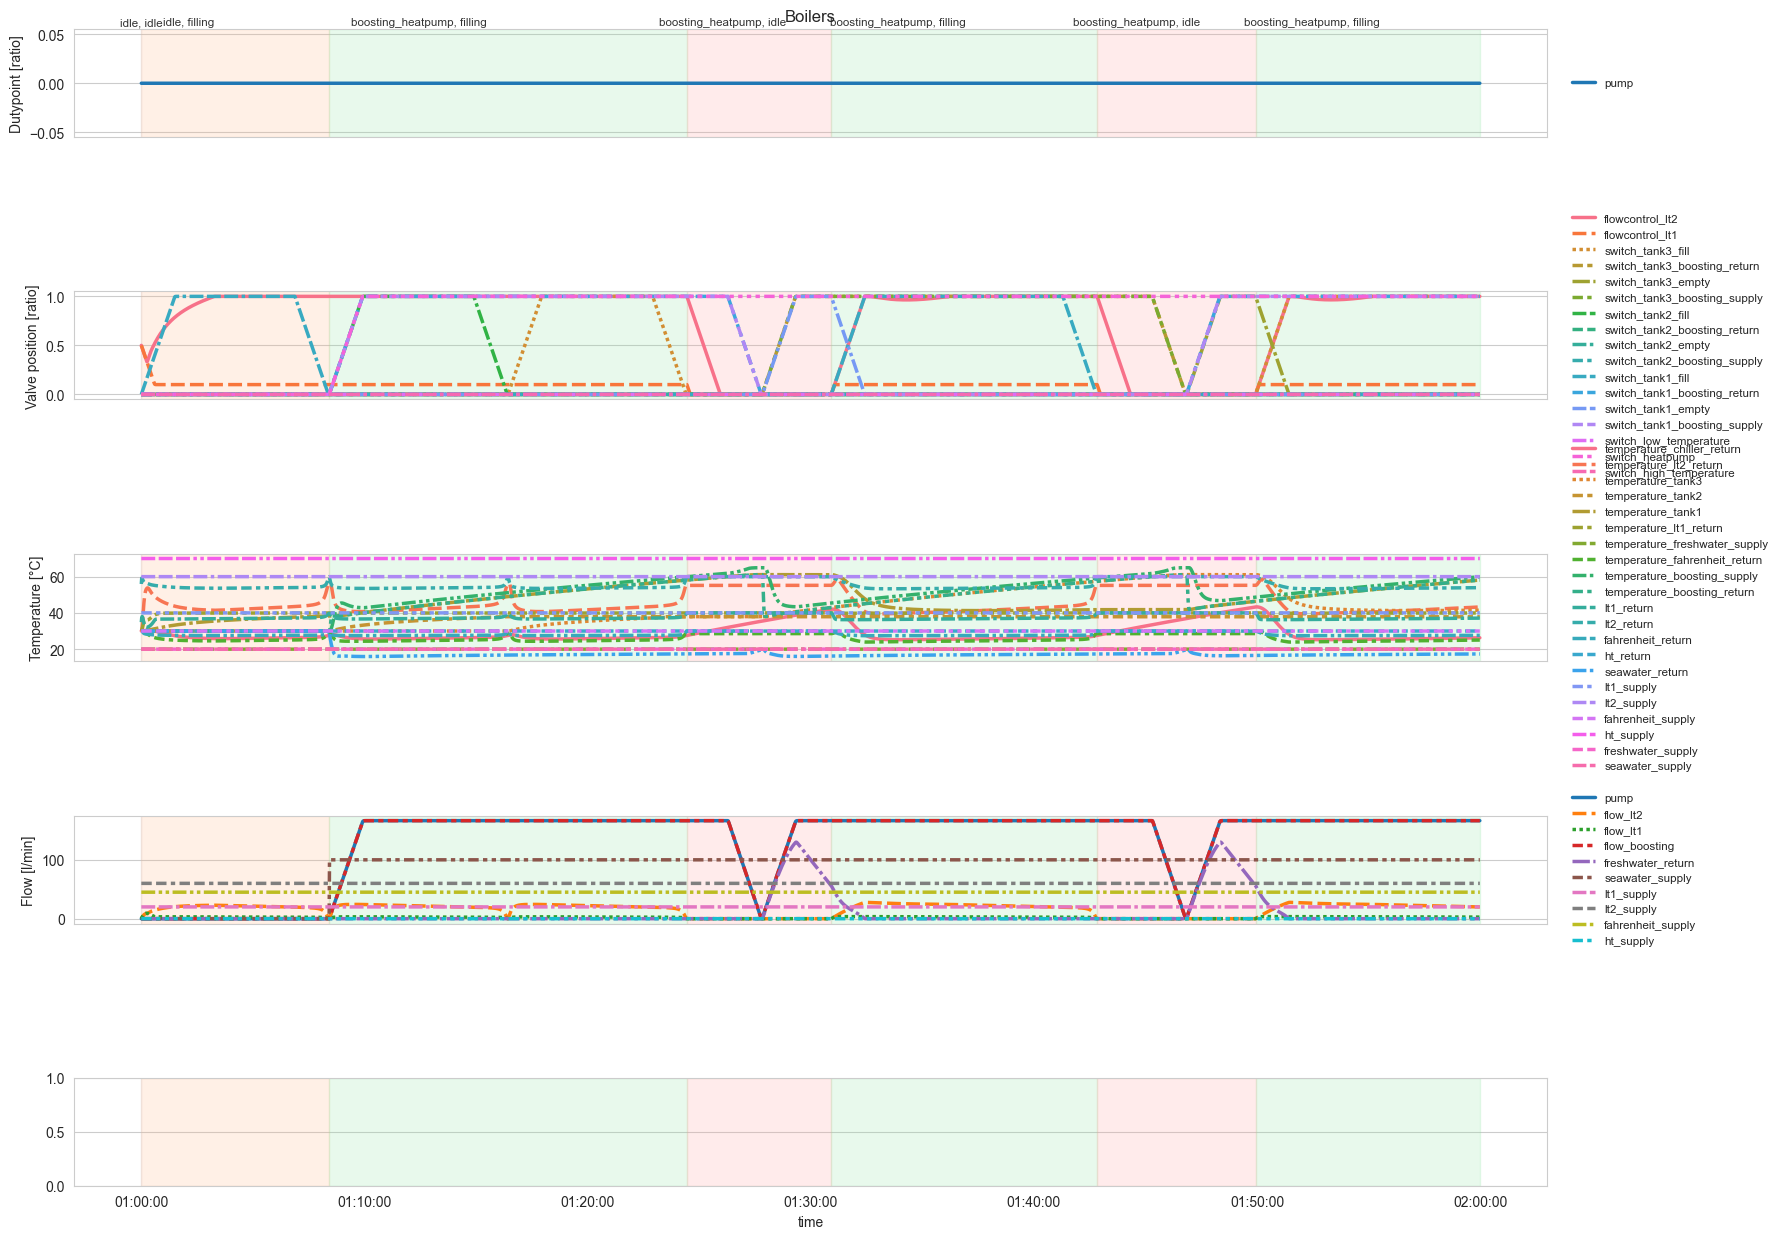

In [41]:
from analysis.analysis_utils import plot_result

plot_result(
    result[
        [
            x
            for x in result.columns
            if (("boilers_" in x) and ("consumers_" not in x))
            or x in ["time", "control_mode"]
        ]
    ],
    "plots/boilers.png",
);

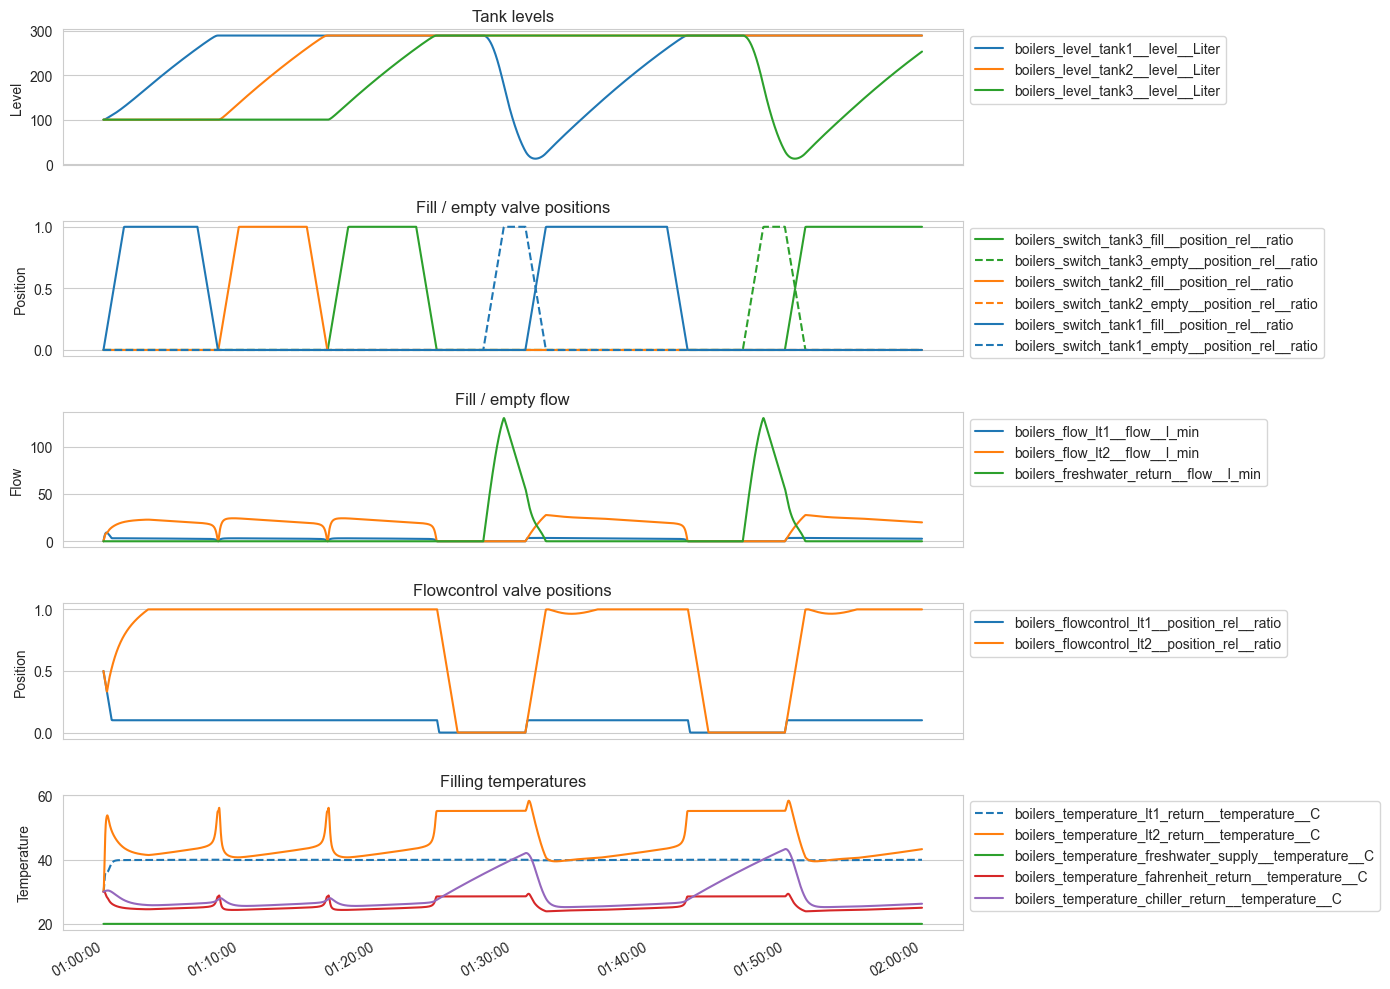

In [42]:
from matplotlib import pyplot as plt
from matplotlib.dates import DateFormatter

levels = [x for x in result.columns if "level" in x]
filling_valves = [
    x for x in result.columns if ("fill" in x or "empty" in x) and ("position_rel" in x)
]
filling_flow = [
    "boilers_flow_lt1__flow__l_min",
    "boilers_flow_lt2__flow__l_min",
    "boilers_freshwater_return__flow__l_min",
]
flowcontrol_valves = [
    "boilers_flowcontrol_lt1__position_rel__ratio",
    "boilers_flowcontrol_lt2__position_rel__ratio",
]
filling_temperatures = [
    "boilers_temperature_lt1_return__temperature__C",
    "boilers_temperature_lt2_return__temperature__C",
    "boilers_temperature_freshwater_supply__temperature__C",
    "boilers_temperature_fahrenheit_return__temperature__C",
    "boilers_temperature_chiller_return__temperature__C",
]


tanks = ["tank1", "tank2", "tank3"]
colors = dict(zip(tanks, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
df = result.to_pandas()


for col in levels:
    tank = next((t for t in tanks if t in col), None)
    axes[0].plot(df["time"], df[col], label=col, color=colors.get(tank))
    axes[0].set_ylabel("Level")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[0].set_title("Tank levels")


for col in filling_valves:
    tank = next((t for t in tanks if t in col), None)
    ls = "--" if "empty" in col else "-"
    axes[1].plot(df["time"], df[col], ls=ls, label=col, color=colors.get(tank))
    axes[1].set_ylabel("Position")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[1].set_title("Fill / empty valve positions")


for col in filling_flow:
    axes[2].plot(df["time"], df[col], label=col)
    axes[2].set_ylabel("Flow")
    axes[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[2].set_title("Fill / empty flow")

for col in flowcontrol_valves:
    axes[3].plot(df["time"], df[col], label=col)
    axes[3].set_ylabel("Position")
    axes[3].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[3].set_title("Flowcontrol valve positions")

for col in filling_temperatures:
    ls = "--" if "lt1" in col else "-"
    axes[4].plot(df["time"], df[col], label=col, ls=ls)
    axes[4].set_ylabel("Temperature")
    axes[4].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[4].set_title("Filling temperatures")

axes[-1].xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

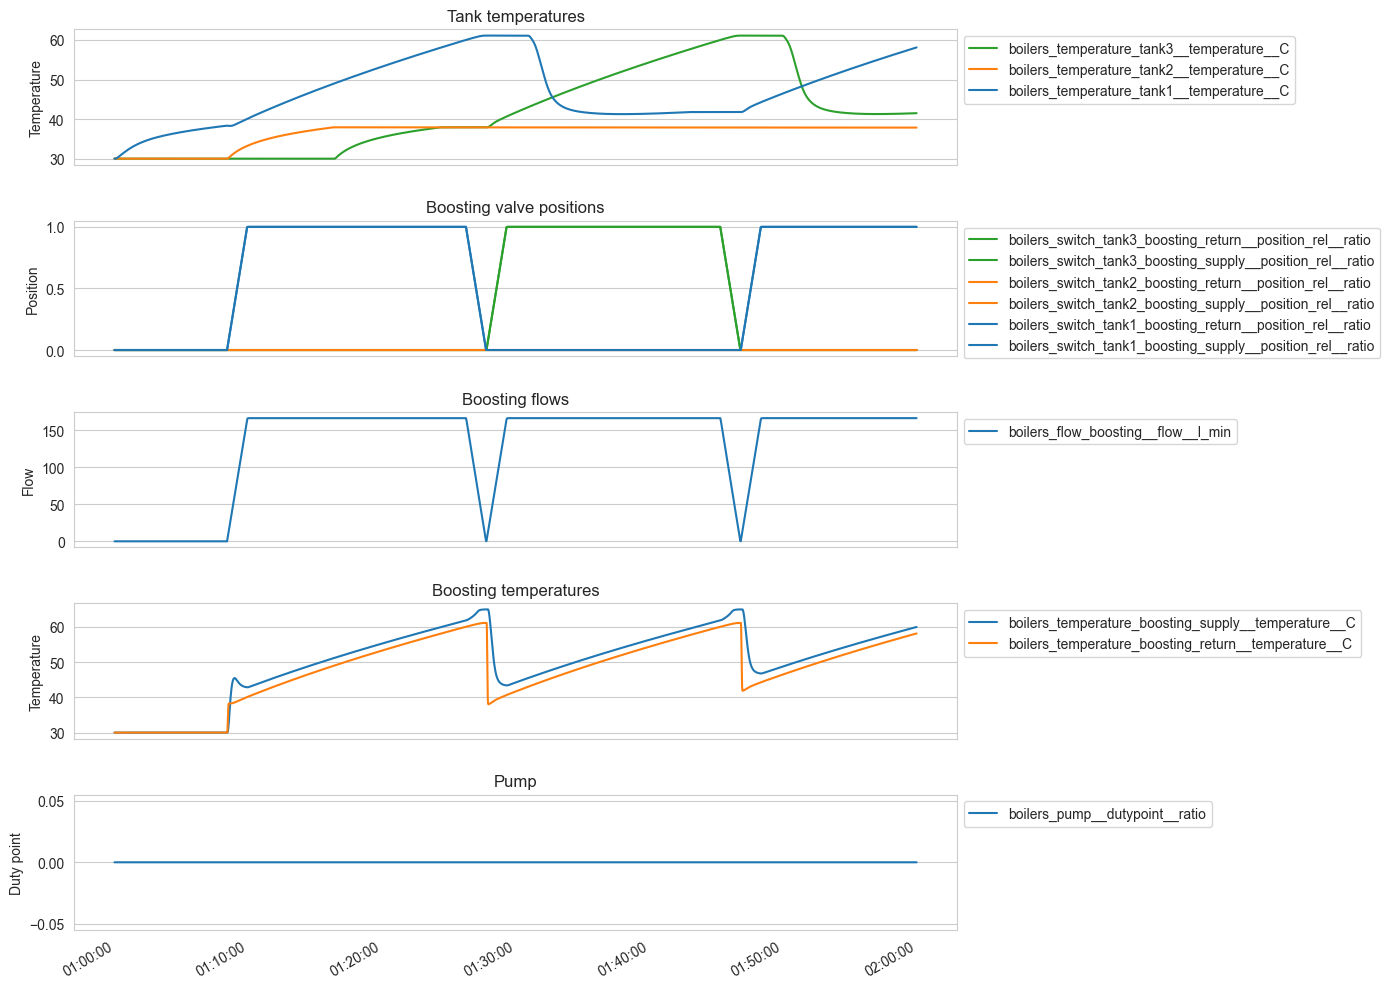

In [43]:
from matplotlib import pyplot as plt

tank_temperatures = [x for x in result.columns if "temperature_tank" in x]
boosting_valves = [
    x
    for x in result.columns
    if ("boosting" in x) and ("switch_tank" in x) and ("position_rel" in x)
]
boosting_flow = [
    x for x in result.columns if ("boilers_flow_boosting" in x) and ("flow__l_min" in x)
]
boosting_temperatures = [
    x for x in result.columns if ("boilers_temperature_boosting" in x)
]


tanks = ["tank1", "tank2", "tank3"]
colors = dict(zip(tanks, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
df = result.to_pandas()


for col in tank_temperatures:
    tank = next((t for t in tanks if t in col), None)
    axes[0].plot(df["time"], df[col], label=col, color=colors.get(tank))
    axes[0].set_ylabel("Temperature")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[0].set_title("Tank temperatures")


for col in boosting_valves:
    tank = next((t for t in tanks if t in col), None)
    ls = "--" if "empty" in col else "-"
    axes[1].plot(df["time"], df[col], ls=ls, label=col, color=colors.get(tank))
    axes[1].set_ylabel("Position")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[1].set_title("Boosting valve positions")


for col in boosting_flow:
    axes[2].plot(df["time"], df[col], label=col)
    axes[2].set_ylabel("Flow")
    axes[2].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[2].set_title("Boosting flows")

for col in boosting_temperatures:
    axes[3].plot(df["time"], df[col], label=col)
    axes[3].set_ylabel("Temperature")
    axes[3].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[3].set_title("Boosting temperatures")

for col in ["boilers_pump__dutypoint__ratio"]:
    axes[4].plot(df["time"], df[col], label=col)
    axes[4].set_ylabel("Duty point")
    axes[4].legend(loc="upper left", bbox_to_anchor=(1, 1))
    axes[4].set_title("Pump")

axes[-1].xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

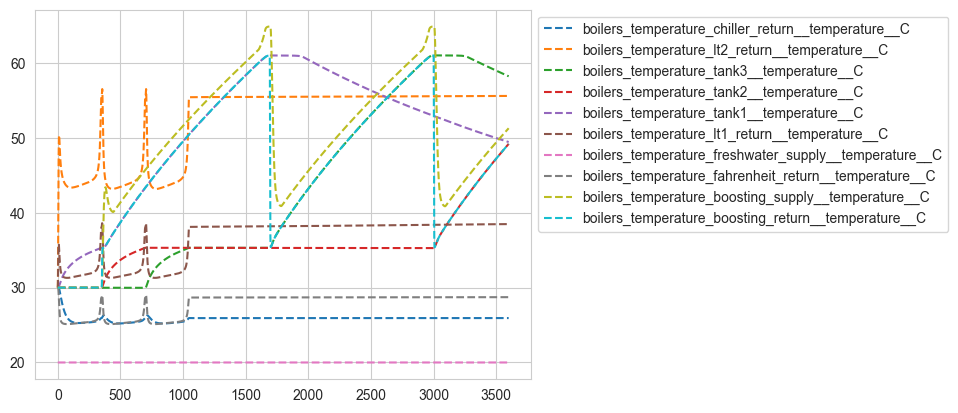

In [28]:
ax = (
    result[[x for x in result.columns if "boilers_temperature" in x]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

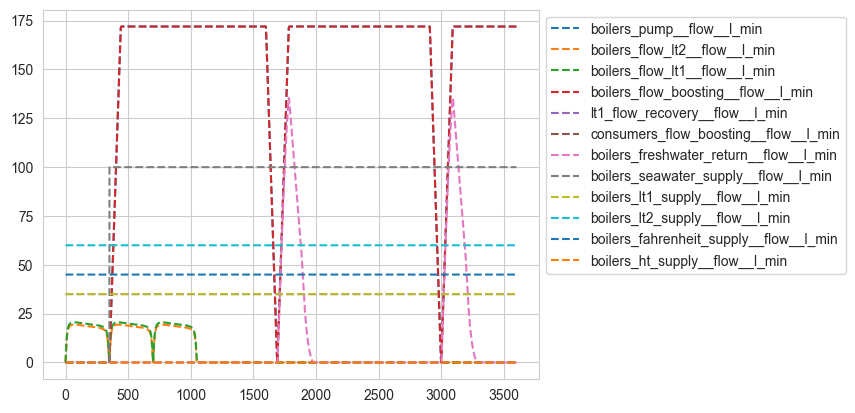

In [29]:
ax = (
    result[[x for x in result.columns if "__flow__l_min" in x]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

In [26]:
from transitions.extensions import GraphMachine

control = BoilersControl(BoilersParameters(), time_fn=datetime.now)
# without further arguments pygraphviz will be used
machine = GraphMachine(
    model=control,
    states=control._states,
    transitions=control._transitions,
    graph_engine="pygraphviz",
    initial="idle",
    show_conditions=True,
    show_state_attributes=True,
)

# draw the whole graph ...
control.get_graph().draw("plots/boilers_state_diagram.png", prog="dot")